<a href="https://colab.research.google.com/github/jramkrishnan/tekmir-challenge/blob/main/tekmir-ds-challenge-jr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd

In [28]:
url = "https://raw.githubusercontent.com/vyuan2037/ds-intern-challenge/main/sample-data/product_usage_events.csv"
df = pd.read_csv(url)
df.head()

,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes
0,2026-08-01,Sales,Lead summary,email,42,35,29,3,8.5,0.74,4.1,normal day
1,2026-08-01,Sales,Lead summary,manual,18,12,8,2,6.0,0.61,3.8,normal day
2,2026-08-01,Support,Reply draft,queue,55,48,39,6,4.5,0.82,4.0,normal day
3,2026-08-01,Support,Reply draft,manual,11,8,5,1,3.0,0.68,NaN,missing rating
4,2026-08-01,Product,Feedback clustering,csv upload,12,9,6,2,14.0,0.59,3.6,small sample


## Cleaning the data

In [29]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,41,7,2026-08-05,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team,41,4,Sales,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
workflow,41,3,Lead summary,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,41,4,manual,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sessions,41.0,NaN,NaN,NaN,35.292683,31.716907,5.0,13.0,24.0,53.0,140.0
completed,41.0,NaN,NaN,NaN,28.073171,28.683088,4.0,10.0,15.0,43.0,126.0
accepted_output,41.0,NaN,NaN,NaN,22.268293,26.661793,2.0,6.0,10.0,35.0,119.0
flagged_for_review,41.0,NaN,NaN,NaN,3.243902,2.808741,1.0,1.0,2.0,4.0,12.0
avg_minutes_saved,41.0,NaN,NaN,NaN,8.139024,3.904157,1.5,4.2,8.4,11.2,14.4
median_confidence,40.0,NaN,NaN,NaN,0.7105,0.118212,0.52,0.625,0.685,0.8025,0.95


In [30]:
pd.set_option("display.max_colwidth", None)

In [31]:
df[df.notes != "normal day"][["date","workflow","notes"]].sort_values("date")

,date,workflow,notes
3,2026-08-01,Reply draft,missing rating
4,2026-08-01,Feedback clustering,small sample
5,2026-08-01,Feedback clustering,small sample
11,2026-08-02,Feedback clustering,team casing differs
18,2026-08-04,Lead summary,new prompt version started
19,2026-08-04,Lead summary,new prompt version started
20,2026-08-04,Reply draft,new prompt version started
21,2026-08-04,Reply draft,new prompt version started
22,2026-08-04,Feedback clustering,new prompt version started
23,2026-08-04,Feedback clustering,new prompt version started


In [32]:
df[df.duplicated(["date","team","workflow","source"], keep=False)]

,date,team,workflow,source,sessions,completed,accepted_output,flagged_for_review,avg_minutes_saved,median_confidence,user_rating,notes
24,2026-08-05,Sales,Lead summary,email,140,126,119,2,12.0,0.95,4.9,traffic spike from demo account
25,2026-08-05,Sales,Lead summary,email,140,126,119,2,12.0,0.95,4.9,duplicate export row


In [33]:
df.team.value_counts()

,count
team,
Sales,14
Support,13
Product,13
product,1


**What we found**

*   14 rows have non normal notes
*   new prompt started oni Aug 4th


*   rows 24 and 25 are the same record
*   product appears alongside Product









**Cleaning**

In [34]:
df["team"] = df["team"].str.title()

In [35]:
print(df.team.value_counts());

team
Sales      14
Product    14
Support    13
Name: count, dtype: int64


In [36]:
df = df.drop([24, 25])
df = df.sort_values("date")

## **Labelling the data before and after prompt change**

In [37]:
df["period"] = df["date"].apply(lambda d: "before" if d < "2026-08-04" else "after")

**Removing confounded data**
Aug 7 had two changes at once for Reply draft: the new prompt (from Aug 4) and a review policy change mid-day. We cannot tell which one caused the flag spike. Removing this row lets us compare the prompt change on its own.

In [38]:
clean = df[~((df.workflow == "Reply draft") & (df.date == "2026-08-07"))].copy()

**Pooling the data to calculate completion, accepatance, flag rate**

In [39]:
pooled = clean.groupby(["workflow","period"])[["sessions","completed","accepted_output","flagged_for_review"]].sum()
pooled["completion_rate"] = pooled.completed / pooled.sessions              # finished / started
pooled["acceptance_rate"] = pooled.accepted_output / pooled.completed       # kept / finished
pooled["flag_rate"] = pooled.flagged_for_review / pooled.completed          # flagged / finished
pooled.round(3)

sessions  completed  accepted_output  \
workflow            period                                         
Feedback clustering after        143         93               61   
                    before        64         45               30   
Lead summary        after        252        196              154   
                    before       198        154              119   
Reply draft         after        264        213              164   
                    before       216        181              139   

                            flagged_for_review  completion_rate  \
workflow            period                                        
Feedback clustering after                   17            0.650   
                    before                   9            0.703   
Lead summary        after                   18            0.778   
                    before                  16            0.778   
Reply draft         after                   33            0.807   
                    before                  24            0.838   

                            acceptance_rate  flag_rate  
workflow            period                              
Feedback clustering after             0.656      0.183  
                    before            0.667      0.200  
Lead summary        after             0.786      0.092  
                    before            0.773      0.104  
Reply draft         after             0.770      0.155  
                    before            0.768      0.133

In [40]:
clean["acceptance_rate"] = clean["accepted_output"] / clean["completed"]
clean.groupby(["workflow","period"]).acceptance_rate.mean().round(3)

workflow             period
Feedback clustering  after     0.648
                     before    0.652
Lead summary         after     0.771
                     before    0.737
Reply draft          after     0.736
                     before    0.712
Name: acceptance_rate, dtype: float64

***Per-row averaging gives different numbers because small-sample days (Aug 1) get the same weight as busy days. Pooled rates are the right call here.***

## **Acceptance rate over time**

In [41]:
df["acceptance_rate"] = df["accepted_output"] / df["completed"]

## **Acceptance rate (users keeping the output) is the strongest signal for whether a workflow is useful. The chart shows one line per workflow, with the Aug 4 prompt change and Aug 7 review policy change marked. If the prompt helped, we'd expect lines to go up after the dashed line.**

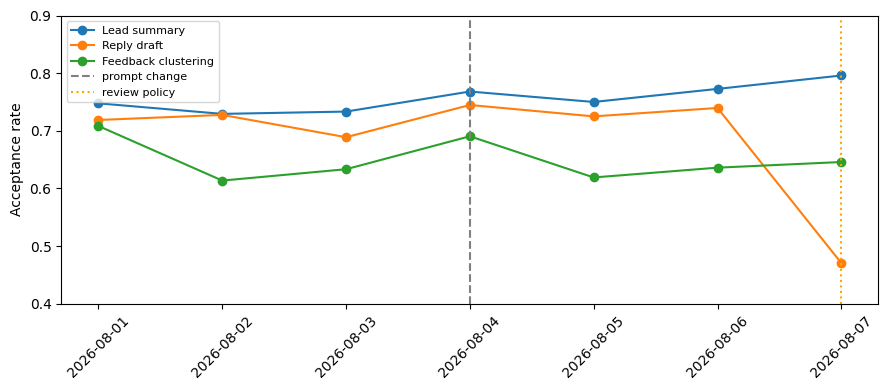

In [42]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4))
for wf in df.workflow.unique():
    daily = df[df.workflow == wf].groupby("date").acceptance_rate.mean()    # average per day for that workflow
    ax.plot(daily.index, daily.values, marker="o", label=wf)
ax.axvline("2026-08-04", color="gray", linestyle="--", label="prompt change")   # mark Aug 4
ax.axvline("2026-08-07", color="orange", linestyle=":", label="review policy")  # mark Aug 7
ax.set_ylim(0.4, 0.9)
ax.set_ylabel("Acceptance rate")
ax.legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Verdict**

Lead summary is the one that's working. Acceptance is around 77% after the change, flags are the lowest of the three, and it's the only workflow that trends up across the week.

The prompt change itself is harder to read. Lead summary went from roughly 74% to 77%, but it moves that much day to day anyway. Feedback clustering didn't move, stuck around 65%. Reply draft looks like it got worse, but almost all of that is Aug 7, the day the review policy changed. Drop that day and Reply draft goes up slightly, 71% to 74%. So the prompt didn't break anything, and I can't say it helped either. Three clean days either side is not much data.

The metric I'd stop trusting is flagged_for_review. On Aug 7 the flag rate for Reply draft roughly tripled and the prompt hadn't changed. That was the policy. If a rules change can swing a metric that hard, it's measuring reviewer behaviour, not output quality.

Before rolling this out wider, ask the Support reviewers whether they flagged more on Aug 7 because the drafts got worse or because the new policy told them to. The data can't answer that. And stop shipping two changes in the same week. That's the whole reason Reply draft is unreadable.

For a weekly check: pooled acceptance rate, pooled flag rate, and total sessions per workflow. Write on the chart whenever a prompt or policy changes, the day it changes.